## Assignment 1: Advanced Pixel-Level Manipulation

## Project Structure
1. Import the required libraries.
2. Load, inspect, and display Image1 and Image2.
3. Manipulate image pixels directly using NumPy array slicing.
4. Crop a random 30×30 region from Image1.
5. Paste the cropped region into Image2 to create Image3.
6. Convert Image1, Image2, and Image3 to grayscale.
7. Apply a sharpening kernel to Image3.
8. Display and compare the final results.

## Step 1: Import libraries

In this step the required libraries are imported. NumPy was used for direct pixel-level manipulation and array slicing. PIL was used to load and process the images, OpenCV was used for grayscale conversion and kernel filtering, and Matplotlib was used to display the results.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

from PIL import Image
from google.colab import files

## Step 2: Upload two images

The two input images are uploaded from the local device into Google Colab.

In [2]:
uploaded = files.upload()

Saving flower.jpg to flower.jpg
Saving cat.jpg to cat.jpg


In [3]:
file_names = list(uploaded.keys())

print("Uploaded files:", file_names)

image1_path = file_names[0]
image2_path = file_names[1]

Uploaded files: ['flower.jpg', 'cat.jpg']


## Step 3: Loading the Images

The two images are loaded using PIL and converted to RGB format. They are then converted into NumPy arrays so that their pixel values can be accessed and manipulated directly.

In [4]:
image1_pil = Image.open("flower.jpg").convert("RGB")
image2_pil = Image.open("cat.jpg").convert("RGB")

#Convert to numpy arrays
image1 = np.array(image1_pil)
image2 = np.array(image2_pil)

print("The images were loaded successfully.")

The images were loaded successfully.


## Step 4: Inspecting the Images

The shape, data type, minimum pixel value, and maximum pixel value of each image are inspected. The shape of an RGB image is represented as height, width, and number of color channels.

In [5]:
print("Image1: Flower")
print("Shape:", image1.shape)
print("Height:", image1.shape[0])
print("Width:", image1.shape[1])
print("Number of channels:", image1.shape[2])
print("Data type:", image1.dtype)
print("Minimum pixel value:", image1.min())
print("Maximum pixel value:", image1.max())

print("\nImage2: Cat")
print("Shape:", image2.shape)
print("Height:", image2.shape[0])
print("Width:", image2.shape[1])
print("Number of channels:", image2.shape[2])
print("Data type:", image2.dtype)
print("Minimum pixel value:", image2.min())
print("Maximum pixel value:", image2.max())

Image1: Flower
Shape: (4000, 6000, 3)
Height: 4000
Width: 6000
Number of channels: 3
Data type: uint8
Minimum pixel value: 0
Maximum pixel value: 255

Image2: Cat
Shape: (333, 592, 3)
Height: 333
Width: 592
Number of channels: 3
Data type: uint8
Minimum pixel value: 0
Maximum pixel value: 255


## Step 5: Displaying the Two Images

The two original images are displayed side by side using Matplotlib. Image1 contains a flower, and Image2 contains a cat.

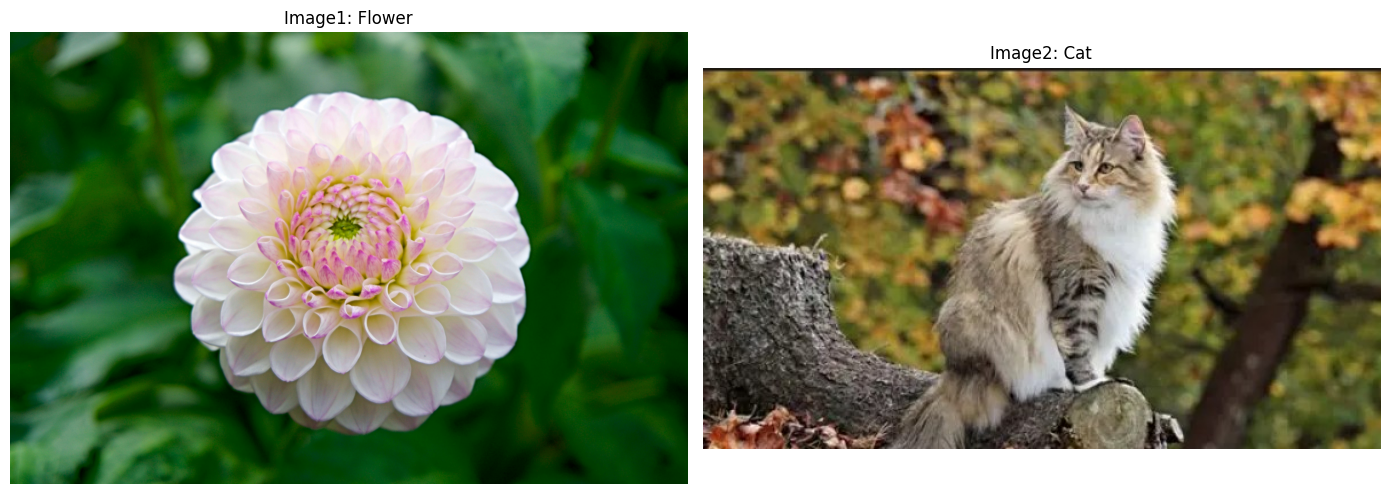

In [6]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(image1)
plt.title("Image1: Flower")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(image2)
plt.title("Image2: Cat")
plt.axis("off")

plt.tight_layout()
plt.show()

## Step 6: Direct Image Matrix Manipulation

An image is represented as a NumPy matrix containing pixel values. A copy of Image1 is created, and a rectangular pixel region is selected directly using array slicing. The RGB values of this region are changed to red. This demonstrates direct manipulation of an image matrix without using a built-in drawing function.

In [7]:
#Making copy to preserve the original image
manipulated_image1 = image1.copy()

#Select a pixel using array
start_y = 100
end_y = 250
start_x = 100
end_x = 300

#Change the selected pixels to red
manipulated_image1[start_y:end_y, start_x:end_x] = [255, 0, 0]

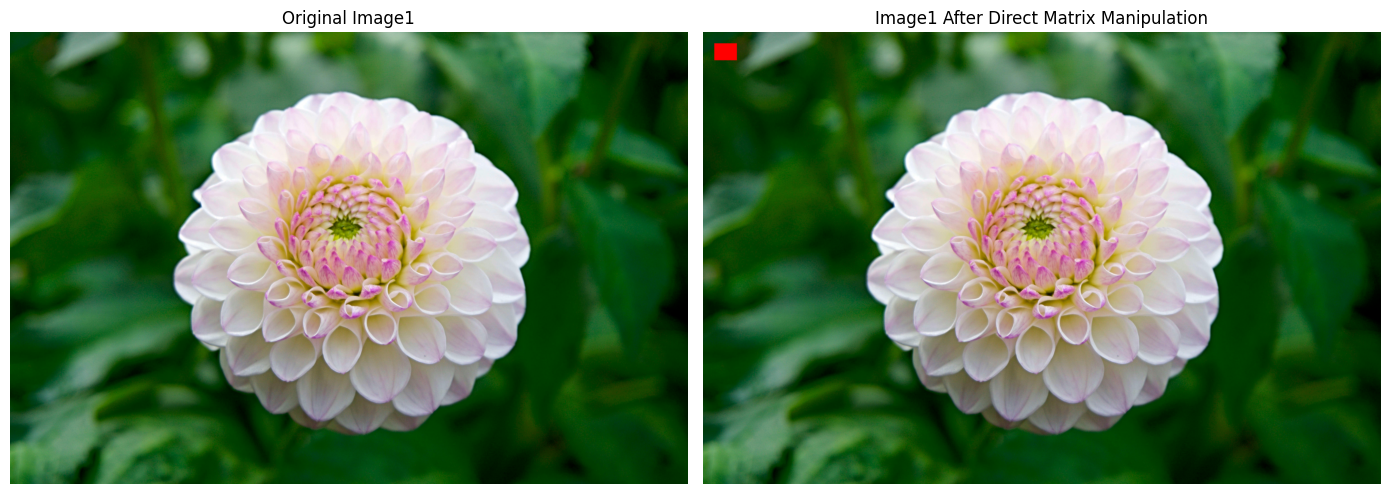

In [8]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(image1)
plt.title("Original Image1")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(manipulated_image1)
plt.title("Image1 After Direct Matrix Manipulation")
plt.axis("off")

plt.tight_layout()
plt.show()

## Step 7: Extracting a Random 30×30 Crop from Image1

Random x and y coordinates are generated within the valid dimensions of Image1. NumPy array slicing is then used to extract a 30×30 pixel region from the randomly selected location.

In [9]:
crop_size = 30

# Get Image1 dimensions
image1_height, image1_width = image1.shape[:2]

# Generate a random valid location
crop_x = np.random.randint(0, image1_width - crop_size + 1)
crop_y = np.random.randint(0, image1_height - crop_size + 1)

# Extract a 30×30 region using array slicing
random_crop = image1[
    crop_y:crop_y + crop_size,
    crop_x:crop_x + crop_size
]

print("Random crop location in Image1:")
print("x1 =", crop_x)
print("y1 =", crop_y)
print("x2 =", crop_x + crop_size)
print("y2 =", crop_y + crop_size)
print("Crop shape:", random_crop.shape)

Random crop location in Image1:
x1 = 4938
y1 = 703
x2 = 4968
y2 = 733
Crop shape: (30, 30, 3)


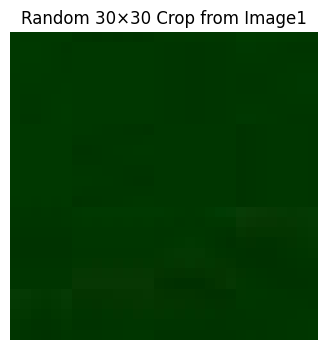

In [10]:
plt.figure(figsize=(4, 4))

plt.imshow(random_crop)
plt.title("Random 30×30 Crop from Image1")
plt.axis("off")

plt.show()

## Step 8: Creating Image3

A copy of Image2 is created and named Image3. Another valid random location is generated inside Image2. The 30×30 crop extracted from Image1 is then pasted into Image3 using NumPy array slicing.

In [11]:
#Create Image3 as copy of Image2
image3 = image2.copy()

#Get Image3 dimensions
image3_height, image3_width = image3.shape[:2]

#Generate a random valid paste location
paste_x = np.random.randint(0, image3_width - crop_size + 1)
paste_y = np.random.randint(0, image3_height - crop_size + 1)

#Paste the crop into Image3
image3[
    paste_y:paste_y + crop_size,
    paste_x:paste_x + crop_size
] = random_crop

print("Random paste location in Image3:")
print("x1 =", paste_x)
print("y1 =", paste_y)
print("x2 =", paste_x + crop_size)
print("y2 =", paste_y + crop_size)

Random paste location in Image3:
x1 = 41
y1 = 124
x2 = 71
y2 = 154


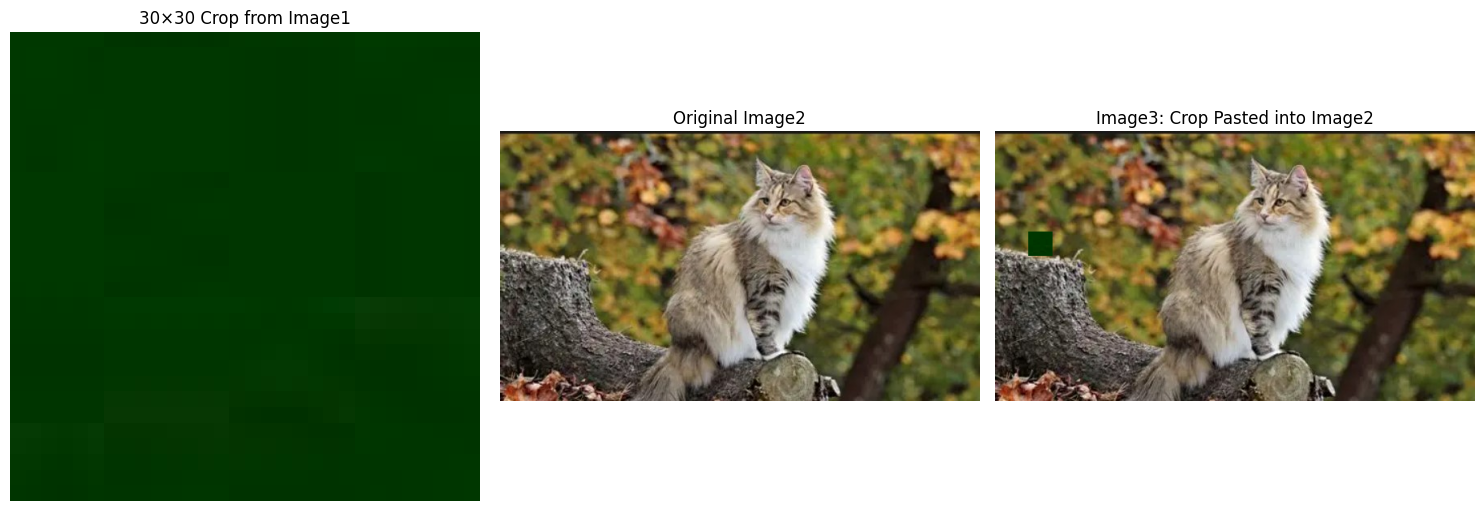

In [12]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(random_crop)
plt.title("30×30 Crop from Image1")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(image2)
plt.title("Original Image2")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(image3)
plt.title("Image3: Crop Pasted into Image2")
plt.axis("off")

plt.tight_layout()
plt.show()

## Step 9: Grayscale Conversion

Image1, Image2, and Image3 are converted from the RGB color space to grayscale using OpenCV. An RGB image contains three color values per pixel, while a grayscale image contains only one intensity value per pixel.

In [13]:
gray_image1 = cv2.cvtColor(image1, cv2.COLOR_RGB2GRAY)
gray_image2 = cv2.cvtColor(image2, cv2.COLOR_RGB2GRAY)
gray_image3 = cv2.cvtColor(image3, cv2.COLOR_RGB2GRAY)

print("RGB Image1 shape:", image1.shape)
print("Grayscale Image1 shape:", gray_image1.shape)

print("\nRGB Image2 shape:", image2.shape)
print("Grayscale Image2 shape:", gray_image2.shape)

print("\nRGB Image3 shape:", image3.shape)
print("Grayscale Image3 shape:", gray_image3.shape)

RGB Image1 shape: (4000, 6000, 3)
Grayscale Image1 shape: (4000, 6000)

RGB Image2 shape: (333, 592, 3)
Grayscale Image2 shape: (333, 592)

RGB Image3 shape: (333, 592, 3)
Grayscale Image3 shape: (333, 592)


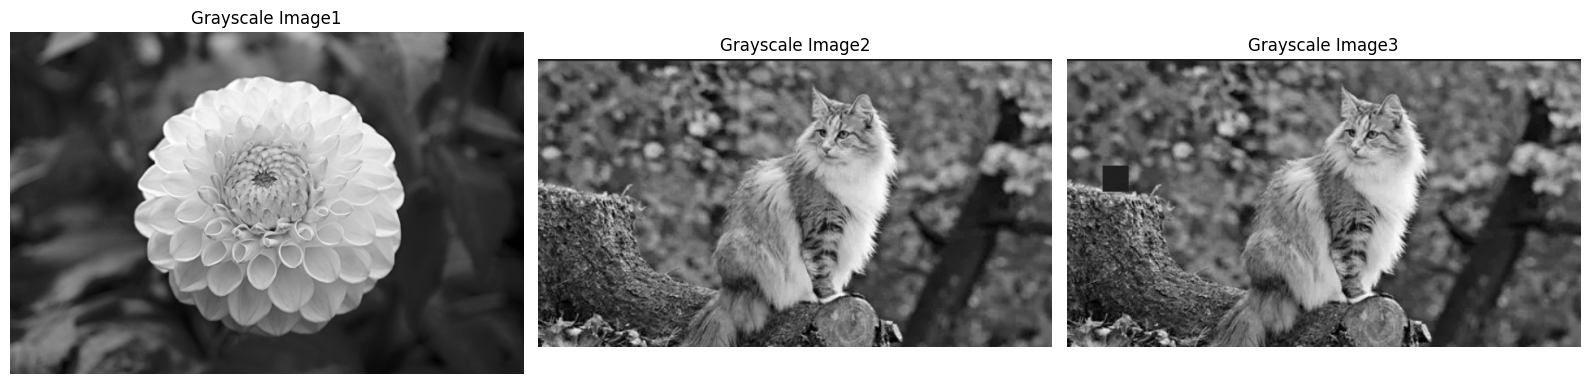

In [14]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 3, 1)
plt.imshow(gray_image1, cmap="gray")
plt.title("Grayscale Image1")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gray_image2, cmap="gray")
plt.title("Grayscale Image2")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(gray_image3, cmap="gray")
plt.title("Grayscale Image3")
plt.axis("off")

plt.tight_layout()
plt.show()

## Step 10: Applying a Sharpening Kernel to Image3

A custom 3×3 sharpening kernel is applied to the grayscale version of Image3 using OpenCV. The positive center value strengthens the current pixel, while the negative surrounding values emphasize the differences between neighboring pixels. As a result, the edges and fine details in Image3 become sharper.

In [15]:
#3×3 sharpening kernel
sharpening_kernel = np.array([
    [-1, -1, -1],
    [-1,  9, -1],
    [-1, -1, -1]
], dtype=np.float32)

print("Sharpening kernel:")
print(sharpening_kernel)

Sharpening kernel:
[[-1. -1. -1.]
 [-1.  9. -1.]
 [-1. -1. -1.]]


In [16]:
#Apply Kernal
sharpened_image3 = cv2.filter2D(
    src=gray_image3,
    ddepth=-1,
    kernel=sharpening_kernel
)

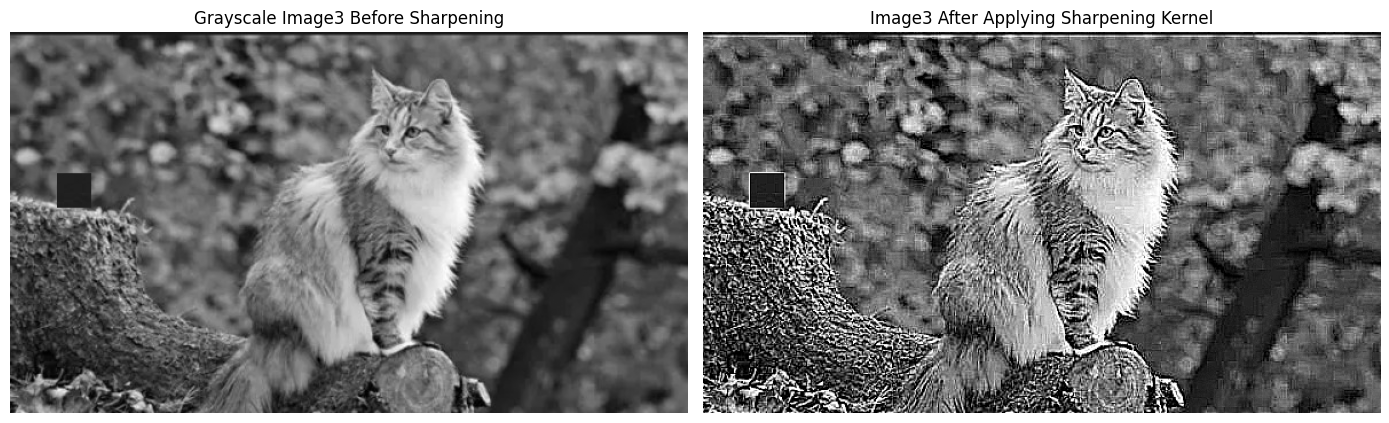

In [17]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(gray_image3, cmap="gray")
plt.title("Grayscale Image3 Before Sharpening")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sharpened_image3, cmap="gray")
plt.title("Image3 After Applying Sharpening Kernel")
plt.axis("off")

plt.tight_layout()
plt.show()

## Conclusion

In this project, two images were loaded, inspected, and displayed using PIL, NumPy, and Matplotlib. Direct pixel-level manipulation was performed by selecting and modifying a region of the Image1 matrix. A random 30×30 pixel region was extracted from Image1 and pasted at a random location in Image2 to create Image3. All three images were then converted from RGB to grayscale. Finally, a custom 3×3 sharpening kernel was applied to Image3 to enhance its edges and fine details.